# NYC Taxi EDA – Tháng 01/2026
**Nhóm 4 – Tuần 1**  
Đọc từ HDFS Bronze layer, khám phá dữ liệu, phát hiện vấn đề chất lượng.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName('NYC_Taxi_EDA_Notebook')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

BRONZE = 'hdfs://namenode:9000/nyc_taxi/bronze/raw/yellow_tripdata_2026-01.parquet'

df = spark.read.parquet(BRONZE)
print(f'Rows: {df.count():,}  |  Cols: {len(df.columns)}')

Rows: 3,724,889  |  Cols: 20


In [3]:
# Schema
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [4]:
# Thống kê mô tả
df.describe('passenger_count','trip_distance','fare_amount','tip_amount','total_amount').show()

26/03/30 11:02:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+-------+------------------+-----------------+------------------+------------------+------------------+
|summary|   passenger_count|    trip_distance|       fare_amount|        tip_amount|      total_amount|
+-------+------------------+-----------------+------------------+------------------+------------------+
|  count|           2636831|          3724889|           3724889|           3724889|           3724889|
|   mean| 1.256271258946819|6.455646860884686| 20.80425389321187|2.6081422399437955|29.178525515824877|
| stddev|0.6702431378098701|648.8855284529193|18.927007021274896| 3.917404766075171|22.585529763602587|
|    min|                 0|              0.0|           -2555.2|            -88.88|           -2560.2|
|    max|                 9|        269097.48|            2555.2|             766.0|            2560.2|
+-------+------------------+-----------------+------------------+------------------+------------------+



In [5]:
# NULL counts
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show(truncate=False)

[Stage 7:=================================================>       (14 + 2) / 16]

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|0       |0                   |0                    |1088058        |0            |1088058   |1088058           |0           |0   

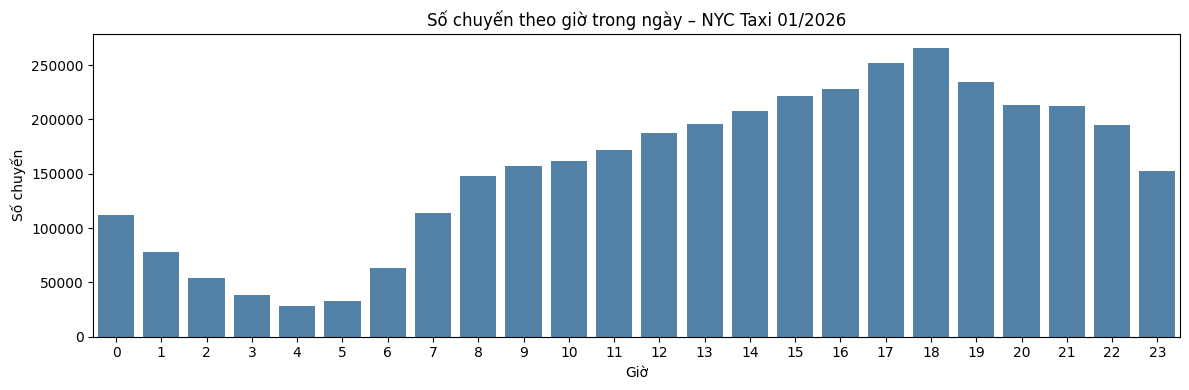

In [6]:
# Phân phối theo giờ – biểu đồ
hourly_pd = (
    df.withColumn('hour', F.hour('tpep_pickup_datetime'))
      .groupBy('hour').count()
      .orderBy('hour')
      .toPandas()
)

plt.figure(figsize=(12, 4))
sns.barplot(data=hourly_pd, x='hour', y='count', color='steelblue')
plt.title('Số chuyến theo giờ trong ngày – NYC Taxi 01/2026')
plt.xlabel('Giờ'); plt.ylabel('Số chuyến')
plt.tight_layout(); plt.show()

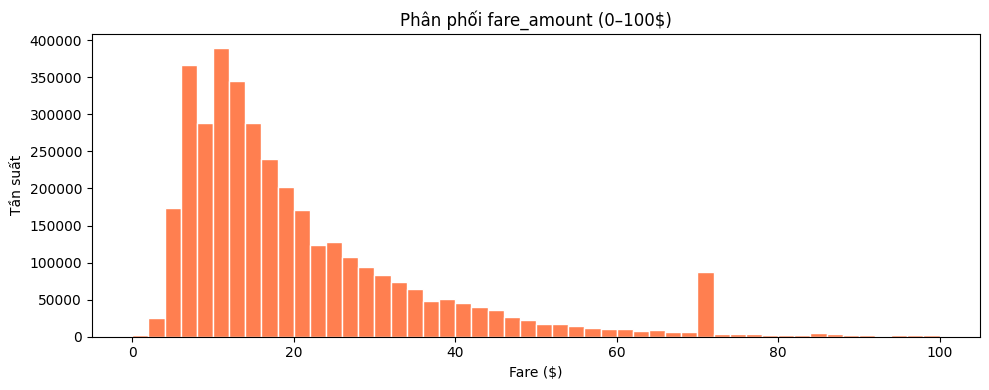

In [7]:
# Phân phối fare_amount
fare_pd = df.select('fare_amount').filter(F.col('fare_amount').between(0, 100)).toPandas()

plt.figure(figsize=(10, 4))
plt.hist(fare_pd['fare_amount'], bins=50, color='coral', edgecolor='white')
plt.title('Phân phối fare_amount (0–100$)')
plt.xlabel('Fare ($)'); plt.ylabel('Tần suất')
plt.tight_layout(); plt.show()

In [8]:
spark.stop()
print('Done')

Done
